### Scaling and Distributing

Before we standardize and split our data, we have to scale **Time** and **Amount** to match the pre-scaled columns. On the other hand, we need to also create a sub sample of the dataframe in order to have an equal amount of Fraud and Non-Fraud cases, helping our algorithms better understand patterns that determines whether a transaction is a fraud or not.

### Why do we need a sub-sample

Our subsample will be a dataframe with a 50/50 ratio of fraud and non-fraud transactions. Meaning our sub-sample will have the same amount of fraud and non fraud transactions.

We saw at the start that the dataframe was heavily imbalanced! Using the original dataframe will cause the following issues:

* **Overfitting**: Our classification models will assume that in most cases there are no frauds! What we want for our model is to be certain when a fraud occurs.

* **Wrong Correlations**: Although we don't know what the "V" features stand for, it will be useful to understand how each of this features influence the result (Fraud or No Fraud) by having an imbalance dataframe we are not able to see the true correlations between the class and features.

### Summary

* **Scaled amount** and **Scaled time** are the columns with scaled values
* There are **492 cases** of fraud in our dataset so we can randomly get 492 cases of non-fraud to create our new sub-dataframe
* We concat the 492 cases of fraud and non-fraud, **creating a new sub-sample**

<a id = "2"></a><br>
# Train Test Split & Standardization

### Splitting our original DataFrame

Before proceeding with the **Random UnderSampling technique**, we have to seperate the original dataframe for testing purposes. Although we are splitting our data with **UnderSampling** or **OverSampling** techniques, we want to test our models on the original testing set. 

The main goal is to fit the model either with the dataframes that were undersample and oversample (in order for our models to detect the patterns), and test it on the original testing set.

In [379]:
sss = StratifiedKFold(n_splits = 5, random_state = None, shuffle = False)

for train_index, test_index in sss.split(X, y):
    print("Train:", train_index, "     Test:", test_index)
    original_Xtrain, original_Xtest = X.iloc[train_index], X.iloc[test_index]
    original_ytrain, original_ytest = y.iloc[train_index], y.iloc[test_index]
    
# We already have X_train and y_train for undersample data thats why I am using original to distinguish and to not overwrite these variables.
# original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(X, y, test_size = 0.2, random_state = 42)

Train: [ 30473  30496  31002 ... 284804 284805 284806]      Test: [    0     1     2 ... 57017 57018 57019]
Train: [     0      1      2 ... 284804 284805 284806]      Test: [ 30473  30496  31002 ... 113964 113965 113966]
Train: [     0      1      2 ... 284804 284805 284806]      Test: [ 81609  82400  83053 ... 170946 170947 170948]
Train: [     0      1      2 ... 284804 284805 284806]      Test: [150654 150660 150661 ... 227866 227867 227868]
Train: [     0      1      2 ... 227866 227867 227868]      Test: [212516 212644 213092 ... 284804 284805 284806]


In [380]:
# Check the Distribution of the labels
# Turn into an array
original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

In [381]:
# See if both the train and test label distribution are similarly distributed
train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts = True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts = True)
print('-' * 100)

print('Label Distributions: \n')
print(train_counts_label/ len(original_ytrain))
print(test_counts_label/ len(original_ytest))

----------------------------------------------------------------------------------------------------
Label Distributions: 

[0.99827076 0.00172924]
[0.99827952 0.00172048]


<a id = "2"></a><br>
# Random Under-Sampling

Now we implement **Random Under Sampling** which basically consists of removing data in order to have a more **balanced dataset** and thus avoiding our models to overfitting

1. The first thing we have to do is determine how **imbalanced** our class is
2. Once we determine how many instances are considered **fraud transactions** (Fraud = 1), we should bring the **non-fraud transactions** to the same amount as fraud transactions (assuming we want a 50/50 ratio). This will be equivalent to 492 cases of fraud and 492 cases of non-fraud transactions.
3. After implementing this technique, we have a sub-sample of our dataframe with a 50/50 ratio with regards to our classes. 

Next we will **shuffle the data** to see if our models can maintain a certain accuracy everytime

In [382]:
# Since our classes are highly skewed we should make them equivalent in order to have a normal distribution of the classes.
# Lets shuffle the data before creating the subsamples

data = data.sample(frac = 1)

In [383]:
# amount of fraud classes 492 rows.
fraud = data.loc[data['Class'] == 1]
non_fraud = data.loc[data['Class'] == 0][:492]

In [384]:
normal_distributed = pd.concat([fraud, non_fraud])

In [385]:
# Shuffle dataframe rows
new_data = normal_distributed.sample(frac = 1, random_state = 42)

new_data.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
185742,-0.029,0.495,2.121,-0.576,-1.038,-0.568,-0.736,-0.888,-0.852,-0.166,-0.138,0.043,0.155,-0.102,1.217,-2.316,0.229,1.533,1.423,-0.669,0.068,0.121,0.271,0.885,0.171,1.077,-0.144,-0.150,0.031,0.002,0
143731,3.057,0.010,-2.208,3.259,-5.436,3.685,-3.066,-0.671,-3.696,1.822,-3.050,-6.354,4.351,-6.453,-0.061,-8.443,-0.329,-5.441,-9.518,-2.438,2.337,0.808,0.921,0.038,0.027,-0.791,0.176,-0.136,1.088,0.374,1
240253,0.741,0.773,-1.321,0.767,0.552,0.653,-0.016,-0.543,0.050,0.429,-1.778,-0.660,-0.610,-0.326,1.005,-2.126,0.701,-1.086,1.934,2.462,-0.551,0.043,-0.347,-0.649,-0.181,-0.312,0.613,-0.348,0.265,0.063,0
150684,-0.293,0.108,-10.041,6.139,-12.973,7.741,-8.685,-3.837,-11.908,5.833,-5.731,-12.439,6.990,-16.219,0.253,-8.729,-0.148,-14.130,-20.685,-8.484,4.851,-0.082,2.823,1.153,-0.567,0.843,0.550,0.114,-0.307,0.062,1
43624,0.244,-0.506,-1.048,1.300,-0.180,2.590,-1.165,0.032,-2.176,0.699,-1.140,-3.227,3.491,-2.454,0.177,-5.161,-0.686,-3.996,-4.696,-1.819,1.461,0.645,0.549,0.624,-0.137,0.132,0.031,-0.177,0.505,0.070,1


<a id = "2"></a><br>
# Data Preprocessing and Analysis (Part 2)

In [386]:
print('Distribution of the Classes in the subsample dataset')
print(new_data['Class'].value_counts()/len(new_data))

Distribution of the Classes in the subsample dataset
1    0.5
0    0.5
Name: Class, dtype: float64


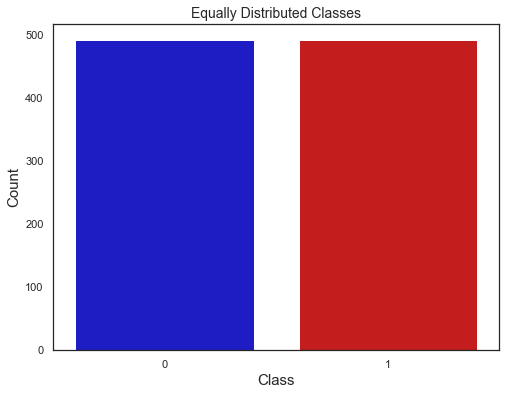

In [387]:
plt.figure(figsize = (8, 6))
sns.countplot('Class', data = new_data, palette = colors)
plt.title('Equally Distributed Classes', fontsize = 14)
plt.xlabel('Class', fontsize = 15)
plt.ylabel('Count', fontsize = 15)
plt.show()

<a id = "2"></a><br>
# Correlation Matrices

Correlation matrices are the essence of understanding our data. We want to know if there are features that influence heavily in whether a specific transaction is a fraud. However, it is important that we use the correct dataframe (subsample) in order for us to see which features have a high positive or negative correlation with regards to fraud transactions.

## Summary

* **Negative Correlations:** V17, V14, V12, and V10 are negatively correlated. Notice how the lower these values are, the more likely the end result will be a fraud transaction.

* **Positive Correlations:** V2, V4, V11, and V19 are positively correlated. Notice how the higher these values are, the more likely the end result will be a fraud transaction.

* **BoxPlots:** We will use boxplots to have a better understanding of the distribution of these features in fradulent and non fradulent transactions.

**Note:** We have to make sure we use the subsample in our correlation matrix or else our correlation matrix will be affected by the high imbalance between our classes. This occurs due to the high class imbalance in the original dataframe.

Text(0.5, 1.0, "Imbalanced Correlation Matrix \n (don't use for reference)")

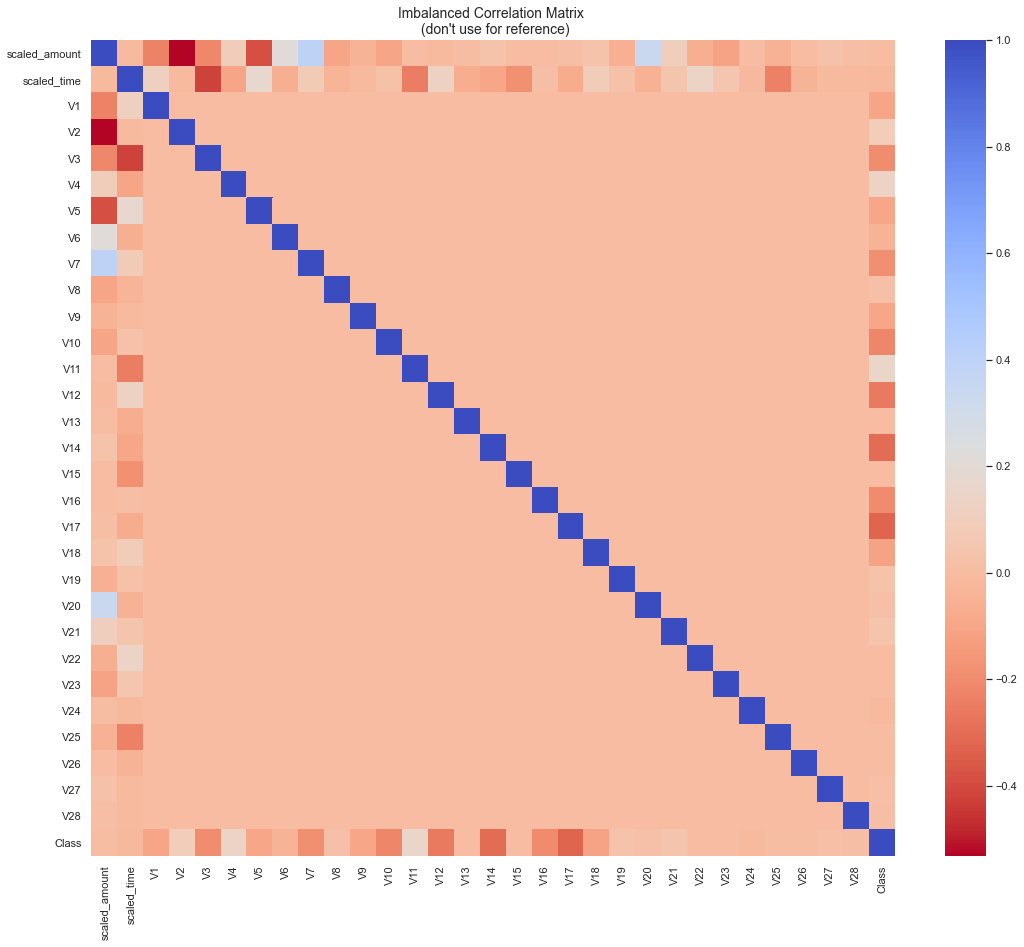

In [388]:
# Entire DataFrame

f, ax = plt.subplots(figsize = (18, 15))
corr = data.corr()
sns.heatmap(corr, cmap = 'coolwarm_r', annot_kws = {'size':20})
plt.title("Imbalanced Correlation Matrix \n (don't use for reference)", fontsize = 14)

Text(0.5, 1.0, 'SubSample Correlation Matrix \n (use for reference)')

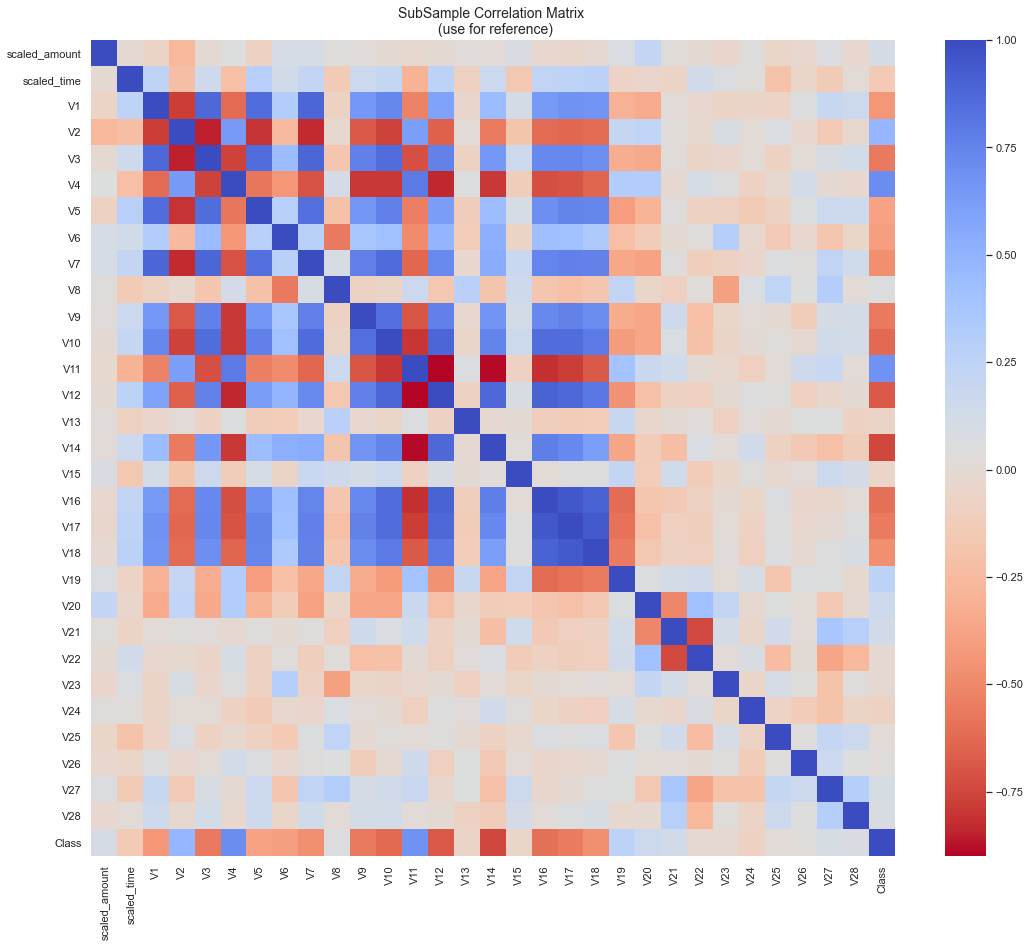

In [389]:
# Subsample DataFrame

f, ax = plt.subplots(figsize = (18, 15))
sub_sample_corr = new_data.corr()
sns.heatmap(sub_sample_corr, cmap = 'coolwarm_r')
plt.title('SubSample Correlation Matrix \n (use for reference)', fontsize = 14)

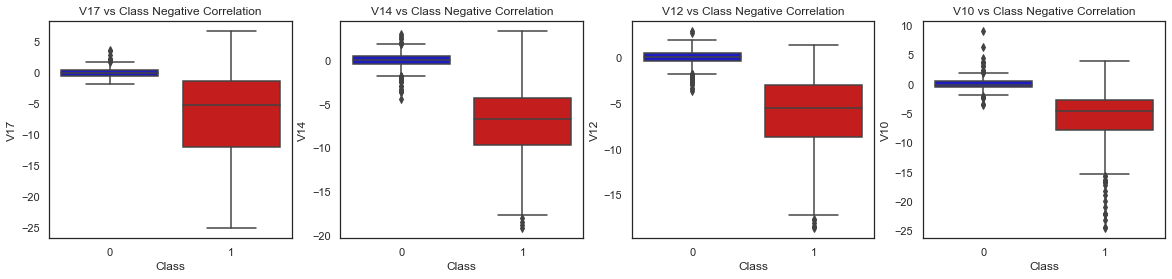

In [390]:
# Negative Correlations with our Class (The lower our feature value the more likely it will be a fraud transaction)

f, axes = plt.subplots(ncols = 4, figsize = (20, 4))

sns.boxplot(x = "Class", y = "V17", data = new_data, palette = colors, ax = axes[0])
axes[0].set_title('V17 vs Class Negative Correlation')

sns.boxplot(x = "Class", y = "V14", data = new_data, palette = colors, ax = axes[1])
axes[1].set_title('V14 vs Class Negative Correlation')

sns.boxplot(x = "Class", y = "V12", data = new_data, palette = colors, ax = axes[2])
axes[2].set_title('V12 vs Class Negative Correlation')

sns.boxplot(x = "Class", y = "V10", data = new_data, palette = colors, ax = axes[3])
axes[3].set_title('V10 vs Class Negative Correlation')

plt.show()

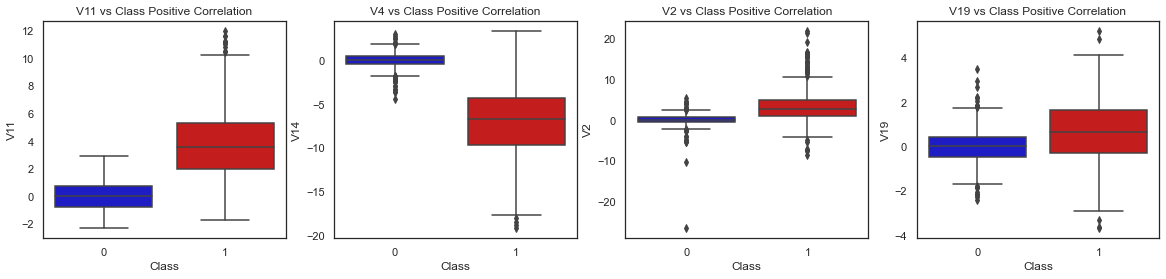

In [391]:
# Positive correlations (The higher the feature the probability increases that it will be a fraud transaction)

f, axes = plt.subplots(ncols = 4, figsize = (20, 4))

sns.boxplot(x = "Class", y = "V11", data = new_data, palette = colors, ax = axes[0])
axes[0].set_title('V11 vs Class Positive Correlation')

sns.boxplot(x = "Class", y = "V14", data = new_data, palette = colors, ax = axes[1])
axes[1].set_title('V4 vs Class Positive Correlation')

sns.boxplot(x = "Class", y = "V2", data = new_data, palette = colors, ax = axes[2])
axes[2].set_title('V2 vs Class Positive Correlation')

sns.boxplot(x = "Class", y = "V19", data = new_data, palette = colors, ax = axes[3])
axes[3].set_title('V19 vs Class Positive Correlation')

plt.show()

<a id = "2"></a><br>
# Anomaly Detection

Our aim is to remove the "extreme outliers" from features that have a high correlation with our classes. This will have a positive impact on the accuracy of our models.

### Interguartile Range Method:

* **Interguartile Range (IGQ):** We calculate this by the difference between the 75th percentile and 25th percentile. Our aim is to create a threshold beyond the 75th and 25th percentile that in case some instance pass this threshold the instance will be deleted.

* **BoxPlots:** Besides easily seeing the 25th and 75th percentiles (both end of the squares) it is also easy to see extreme outliers (points beyond the lower and higher extreme).

### Outlier Removeal Tradeoff:

We have to be careful as to how far do we want the threshold for removing outliers. We determine the threshold by multiplying a number (ex: 1.5) by the (Interquartile Range). The higher this threshold is, the less outliers will detect (multiplying by a higher number ex: 3), and the lower this threshold is the more outliers it will detect. 

**The Tradeoff:** The lower the threshold the more outliers it will remove however, we want to focus more on "extreme outliers" rather than just outliers. Why? because we might run the risk of information loss which will cause our models to have a lower accuracy. You can play with this threshold and see how it affects the accuracy of our classification models.

### Summary

* **Visualize Distributions:** We first start by visualizing the distribution of the feature we are going to use to eliminate some of the outliers. V14 is the only feature that has a Gaussian distribution compared to features V12 and V10.

* **Determining the threshold:** After we decide which number we will use to multiply with the IQR (the lower more outliers removed), we will proceed in determining the upper and lower thresholds by substrating q25 - threshold (lower extreme threshold) and adding q75 + threshold (upper extreme threshold).

* **BoxPlot Representation:** Visualize through the boxplot that the number of "extreme outliers" have been reduced to a considerable amount.

**Note:** After implementing outlier reduction our accuracy has been improved by over 3%! Some outliers can distort the accuracy of our models but remember, we have to avoid an extreme amount of information loss or else our model runs the risk of underfitting.

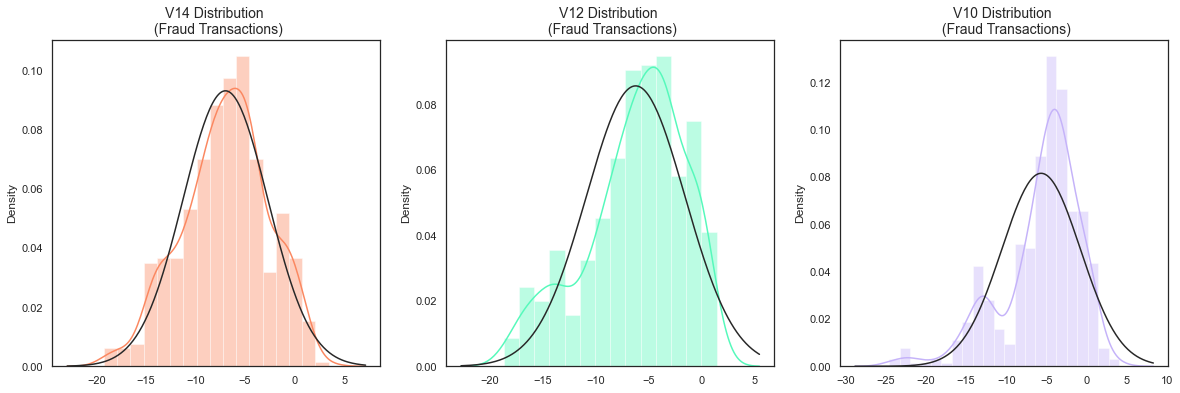

In [392]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (20, 6))

v14_fraud_dist = new_data['V14'].loc[new_data['Class'] == 1].values
sns.distplot(v14_fraud_dist, ax = ax1, fit = norm, color = '#FB8861')
ax1.set_title('V14 Distribution \n (Fraud Transactions)', fontsize = 14)

v12_fraud_dist = new_data['V12'].loc[new_data['Class'] == 1].values
sns.distplot(v12_fraud_dist, ax = ax2, fit = norm, color = '#56F9BB')
ax2.set_title('V12 Distribution \n (Fraud Transactions)', fontsize = 14)


v10_fraud_dist = new_data['V10'].loc[new_data['Class'] == 1].values
sns.distplot(v10_fraud_dist, ax = ax3, fit = norm, color = '#C5B3F9')
ax3.set_title('V10 Distribution \n (Fraud Transactions)', fontsize = 14)

plt.show()

In [393]:
# -----> V14 Removing Outliers (Highest Negative Correlated with Labels)
v14_fraud = new_data['V14'].loc[new_data['Class'] == 1].values
q25, q75 = np.percentile(v14_fraud, 25), np.percentile(v14_fraud, 75)
print('Quartile 25: {} | Quartile 75: {}'.format(q25, q75))

v14_iqr = q75 - q25
print('iqr: {}'.format(v14_iqr))

v14_cut_off = v14_iqr * 1.5
v14_lower, v14_upper = q25 - v14_cut_off, q75 + v14_cut_off
print('Cut Off: {}'.format(v14_cut_off))
print('V14 Lower: {}'.format(v14_lower))
print('V14 Upper: {}'.format(v14_upper))

outliers = [x for x in v14_fraud if x < v14_lower or x > v14_upper]
print('Feature V14 Outliers for Fraud Cases: {}'.format(len(outliers)))
print('V10 outliers:{}'.format(outliers))

new_data = new_data.drop(new_data[(new_data['V14'] > v14_upper) | (new_data['V14'] < v14_lower)].index)
print('----' * 28)

Quartile 25: -9.692722964972385 | Quartile 75: -4.282820849486866
iqr: 5.409902115485519
Cut Off: 8.114853173228278
V14 Lower: -17.807576138200663
V14 Upper: 3.8320323237414122
Feature V14 Outliers for Fraud Cases: 4
V10 outliers:[-18.8220867423816, -18.049997689859396, -19.2143254902614, -18.4937733551053]
----------------------------------------------------------------------------------------------------------------


In [394]:
# -----> V12 removing outliers from fraud transactions
v12_fraud = new_data['V12'].loc[new_data['Class'] == 1].values
q25, q75 = np.percentile(v12_fraud, 25), np.percentile(v12_fraud, 75)
v12_iqr = q75 - q25

v12_cut_off = v12_iqr * 1.5
v12_lower, v12_upper = q25 - v12_cut_off, q75 + v12_cut_off
print('V12 Lower: {}'.format(v12_lower))
print('V12 Upper: {}'.format(v12_upper))

outliers = [x for x in v12_fraud if x < v12_lower or x > v12_upper]
print('V12 outliers: {}'.format(outliers))
print('Feature V12 Outliers for Fraud Cases: {}'.format(len(outliers)))

new_data = new_data.drop(new_data[(new_data['V12'] > v12_upper) | (new_data['V12'] < v12_lower)].index)
print('Number of Instances after outliers removal: {}'.format(len(new_data)))
print('----' * 28)

V12 Lower: -17.3430371579634
V12 Upper: 5.776973384895937
V12 outliers: [-18.553697009645802, -18.047596570821604, -18.683714633344298, -18.4311310279993]
Feature V12 Outliers for Fraud Cases: 4
Number of Instances after outliers removal: 976
----------------------------------------------------------------------------------------------------------------


In [395]:
# Removing outliers V10 Feature
v10_fraud = new_data['V10'].loc[new_data['Class'] == 1].values
q25, q75 = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
v10_iqr = q75 - q25

v10_cut_off = v10_iqr * 1.5
v10_lower, v10_upper = q25 - v10_cut_off, q75 + v10_cut_off
print('V10 Lower: {}'.format(v10_lower))
print('V10 Upper: {}'.format(v10_upper))

outliers = [x for x in v10_fraud if x < v10_lower or x > v10_upper]
print('V10 outliers: {}'.format(outliers))
print('Feature V10 Outliers for Fraud Cases: {}'.format(len(outliers)))

new_data = new_data.drop(new_data[(new_data['V10'] > v10_upper) | (new_data['V10'] < v10_lower)].index)
print('Number of Instances after outliers removal: {}'.format(len(new_data)))

V10 Lower: -14.89885463232024
V10 Upper: 4.920334958342141
V10 outliers: [-16.6496281595399, -14.9246547735487, -19.836148851696, -15.124162814494698, -24.403184969972802, -15.563791338730098, -24.5882624372475, -23.2282548357516, -15.1237521803455, -16.3035376590131, -15.563791338730098, -15.346098846877501, -18.2711681738888, -22.1870885620007, -22.1870885620007, -16.2556117491401, -18.9132433348732, -15.2318333653018, -22.1870885620007, -17.141513641289198, -15.2399619587112, -22.1870885620007, -15.2399619587112, -16.7460441053944, -14.9246547735487, -16.6011969664137, -20.949191554361104]
Feature V10 Outliers for Fraud Cases: 27
Number of Instances after outliers removal: 947


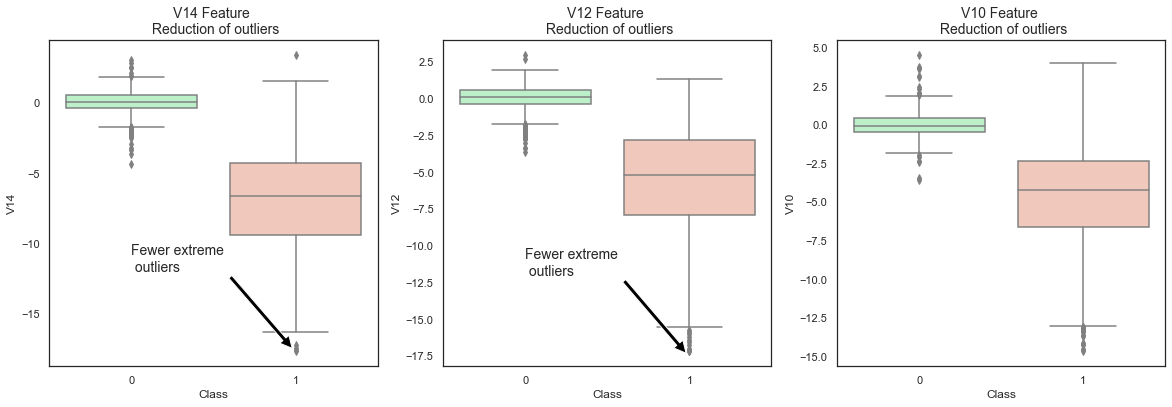

In [396]:
f,(ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (20,6))

colors = ['#B3F9C5', '#f9c5b3']
# Boxplots with outliers removed
# Feature V14
sns.boxplot(x = "Class", y = "V14", data = new_data, ax = ax1, palette = colors)
ax1.set_title("V14 Feature \n Reduction of outliers", fontsize = 14)
ax1.annotate('Fewer extreme \n outliers', xy = (0.98, -17.5), xytext = (0, -12),
            arrowprops = dict(facecolor = 'black'), fontsize = 14)

# Feature 12
sns.boxplot(x = "Class", y = "V12", data = new_data, ax = ax2, palette = colors)
ax2.set_title("V12 Feature \n Reduction of outliers", fontsize = 14)
ax2.annotate('Fewer extreme \n outliers', xy = (0.98, -17.3), xytext = (0, -12),
            arrowprops = dict(facecolor = 'black'), fontsize = 14)

# Feature V10
sns.boxplot(x = "Class", y = "V10", data = new_data, ax = ax3, palette = colors)
ax3.set_title("V10 Feature \n Reduction of outliers", fontsize = 14)
ax3.annotate('Fewer extreme \n outliers', xy = (0.95, -16.5), xytext = (0, -12),
            arrowprops = dict(facecolor = 'black'), fontsize = 14)

plt.show()

<a id = "2"></a><br>
# Dimensionality Reduction and Clustering

In [397]:
# New_data is from the random undersample data (fewer instances)
X = new_data.drop('Class', axis = 1)
y = new_data['Class']

In [398]:
# T-SNE Implementation
t0 = time.time()
X_reduced_tsne = TSNE(n_components = 2, random_state = 42).fit_transform(X.values)
t1 = time.time()
print("T-SNE took {:.2} s".format(t1 - t0))

T-SNE took 2.4 s


In [399]:
# PCA Implementation
t0 = time.time()
X_reduced_pca = PCA(n_components = 2, random_state = 42).fit_transform(X.values)
t1 = time.time()
print("PCA took {:.2} s".format(t1 - t0))

PCA took 0.0045 s


In [400]:
# TruncatedSVD
t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components = 2, algorithm = 'randomized', random_state = 42).fit_transform(X.values)
t1 = time.time()
print("Truncated SVD took {:.2} s".format(t1 - t0))

Truncated SVD took 0.004 s


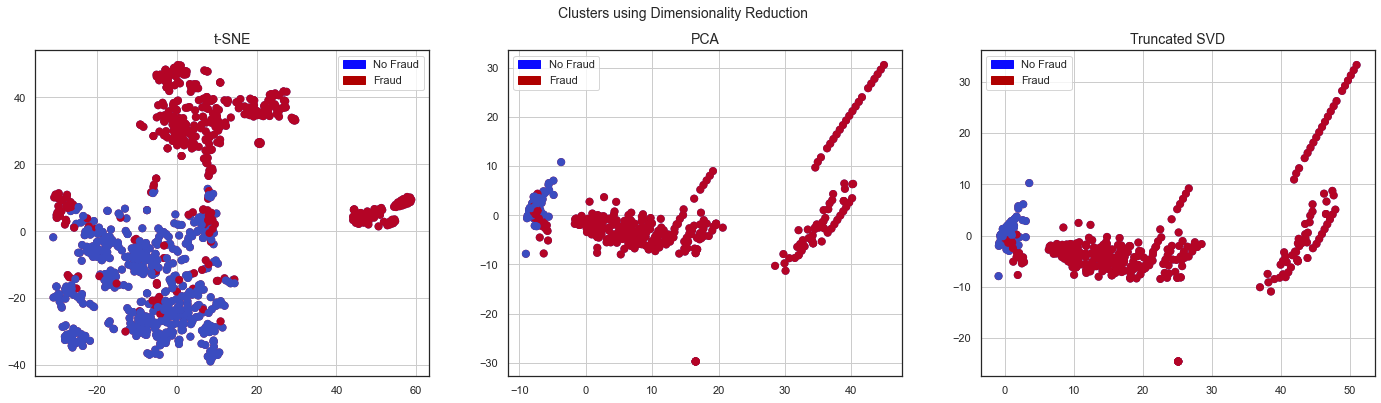

In [401]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (24,6))
# labels = ['No Fraud', 'Fraud']
f.suptitle('Clusters using Dimensionality Reduction', fontsize = 14)


blue_patch = mpatches.Patch(color = '#0A0AFF', label = 'No Fraud')
red_patch = mpatches.Patch(color = '#AF0000', label = 'Fraud')


# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c = (y == 0), cmap = 'coolwarm', label = 'No Fraud', linewidths = 2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c = (y == 1), cmap = 'coolwarm', label = 'Fraud', linewidths = 2)
ax1.set_title('t-SNE', fontsize = 14)

ax1.grid(True)

ax1.legend(handles=[blue_patch, red_patch])


# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c = (y == 0), cmap = 'coolwarm', label = 'No Fraud', linewidths = 2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c = (y == 1), cmap = 'coolwarm', label = 'Fraud', linewidths = 2)
ax2.set_title('PCA', fontsize = 14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c = (y == 0), cmap = 'coolwarm', label = 'No Fraud', linewidths = 2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c = (y == 1), cmap = 'coolwarm', label = 'Fraud', linewidths = 2)
ax3.set_title('Truncated SVD', fontsize = 14)

ax3.grid(True)

ax3.legend(handles = [blue_patch, red_patch])

plt.show()

<a id = "2"></a><br>
# Classifiers (UnderSampling)

Now we will train four types of classifier and decide which classifier will be more effective in detecting **fraud transactions**. Before we have to split our data into training and testing sets and separate the features from the labels.

### Summary

* **Logistic Regression** classifier is more accurate than the other three classifiers in most cases. 

* **GridSearchCV** is used to determine the paremeters that gives the best predictive score for the classifiers.

* **Logistic Regression** has the best Receiving Operating Characteristic score (ROC), meaning that LogisticRegression pretty accurately separates **fraud** and **non-fraud** transactions.

### Learning Curves

* The **wider the gap** between the training score and the cross validation score, the more likely your model is **overfitting (high variance).**

* If the score is low in both training and cross-validation sets this is an indication that our model is **underfitting (high bias)**

* **Logistic Regression Classifier** shows the best score in both training and cross-validating sets.

In [402]:
# Undersampling before cross validating (prone to overfit)
X = new_data.drop('Class', axis = 1)
y = new_data['Class']

In [403]:
# Our data is already scaled we should split our training and test sets

# This is explicitly used for undersampling.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [404]:
# Turn the values into an array for feeding the classification algorithms.
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [405]:
# Let's implement simple classifiers

classifiers = {
    "LogisiticRegression": LogisticRegression(),
    "KNearest": KNeighborsClassifier(),
    "Support Vector Classifier": SVC(),
    "DecisionTreeClassifier": DecisionTreeClassifier()
}

In [406]:
# Wow our scores are getting even high scores even when applying cross validation.

for key, classifier in classifiers.items():
    classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv = 5)
    print("Classifiers: ", classifier.__class__.__name__, "Has a training score of", round(training_score.mean(), 2) * 100, "% accuracy score")

Classifiers:  LogisticRegression Has a training score of 93.0 % accuracy score
Classifiers:  KNeighborsClassifier Has a training score of 93.0 % accuracy score
Classifiers:  SVC Has a training score of 92.0 % accuracy score
Classifiers:  DecisionTreeClassifier Has a training score of 89.0 % accuracy score


In [407]:
# Use GridSearchCV to find the best parameters.

# Logistic Regression 
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid_log_reg = GridSearchCV(LogisticRegression(), log_reg_params)
grid_log_reg.fit(X_train, y_train)

# We automatically get the logistic regression with the best parameters.
log_reg = grid_log_reg.best_estimator_

In [408]:
knears_params = {"n_neighbors": list(range(2,5,1)), 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}

grid_knears = GridSearchCV(KNeighborsClassifier(), knears_params)
grid_knears.fit(X_train, y_train)

# KNears best estimator
knears_neighbors = grid_knears.best_estimator_

In [409]:
# Support Vector Classifier
svc_params = {'C': [0.5, 0.7, 0.9, 1], 'kernel': ['rbf', 'poly', 'sigmoid', 'linear']}
grid_svc = GridSearchCV(SVC(), svc_params)
grid_svc.fit(X_train, y_train)

# SVC best estimator
svc = grid_svc.best_estimator_

In [410]:
# DecisionTree Classifier
tree_params = {"criterion": ["gini", "entropy"], "max_depth": list(range(2,4,1)), 
              "min_samples_leaf": list(range(5,7,1))}
grid_tree = GridSearchCV(DecisionTreeClassifier(), tree_params)
grid_tree.fit(X_train, y_train)

# tree best estimator
tree_clf = grid_tree.best_estimator_

In [411]:
# Overfitting Case

log_reg_score = cross_val_score(log_reg, X_train, y_train, cv = 5)
print('Logistic Regression Cross Validation Score: ', round(log_reg_score.mean() * 100, 2).astype(str) + '%')


knears_score = cross_val_score(knears_neighbors, X_train, y_train, cv = 5)
print('Knears Neighbors Cross Validation Score', round(knears_score.mean() * 100, 2).astype(str) + '%')

svc_score = cross_val_score(svc, X_train, y_train, cv = 5)
print('Support Vector Classifier Cross Validation Score', round(svc_score.mean() * 100, 2).astype(str) + '%')

tree_score = cross_val_score(tree_clf, X_train, y_train, cv = 5)
print('DecisionTree Classifier Cross Validation Score', round(tree_score.mean() * 100, 2).astype(str) + '%')

Logistic Regression Cross Validation Score:  93.4%
Knears Neighbors Cross Validation Score 93.13%
Support Vector Classifier Cross Validation Score 92.07%
DecisionTree Classifier Cross Validation Score 92.47%


In [412]:
# We will undersample during cross validating
undersample_X = data.drop('Class', axis = 1)
undersample_y = data['Class']

for train_index, test_index in sss.split(undersample_X, undersample_y):
    print("Train:", train_index, "Test:", test_index)
    undersample_Xtrain, undersample_Xtest = undersample_X.iloc[train_index], undersample_X.iloc[test_index]
    undersample_ytrain, undersample_ytest = undersample_y.iloc[train_index], undersample_y.iloc[test_index]
    
undersample_Xtrain = undersample_Xtrain.values
undersample_Xtest = undersample_Xtest.values
undersample_ytrain = undersample_ytrain.values
undersample_ytest = undersample_ytest.values 

undersample_accuracy = []
undersample_precision = []
undersample_recall = []
undersample_f1 = []
undersample_auc = []

# Implementing NearMiss Technique 
# Distribution of NearMiss (Just to see how it distributes the labels we won't use these variables)
X_nearmiss, y_nearmiss = NearMiss().fit_sample(undersample_X.values, undersample_y.values)
print('NearMiss Label Distribution: {}'.format(Counter(y_nearmiss)))
# Cross Validating the right way

for train, test in sss.split(undersample_Xtrain, undersample_ytrain):
    # SMOTE happens during Cross Validation not before..
    undersample_pipeline = imbalanced_make_pipeline(NearMiss(sampling_strategy = 'majority'), log_reg) 
    undersample_model = undersample_pipeline.fit(undersample_Xtrain[train], undersample_ytrain[train])
    undersample_prediction = undersample_model.predict(undersample_Xtrain[test])
    
    undersample_accuracy.append(undersample_pipeline.score(original_Xtrain[test], original_ytrain[test]))
    undersample_precision.append(precision_score(original_ytrain[test], undersample_prediction))
    undersample_recall.append(recall_score(original_ytrain[test], undersample_prediction))
    undersample_f1.append(f1_score(original_ytrain[test], undersample_prediction))
    undersample_auc.append(roc_auc_score(original_ytrain[test], undersample_prediction))

Train: [ 49625  50291  50924 ... 284804 284805 284806] Test: [    0     1     2 ... 56970 56971 56972]
Train: [     0      1      2 ... 284804 284805 284806] Test: [ 49625  50291  50924 ... 113921 114899 115648]
Train: [     0      1      2 ... 284804 284805 284806] Test: [113922 113923 113924 ... 170882 170883 171415]
Train: [     0      1      2 ... 284804 284805 284806] Test: [170884 170885 170886 ... 227846 227847 227848]
Train: [     0      1      2 ... 227846 227847 227848] Test: [225446 226330 227162 ... 284804 284805 284806]
NearMiss Label Distribution: Counter({0: 492, 1: 492})


In [413]:
# Let's Plot LogisticRegression Learning Curve

def plot_learning_curve(estimator1, estimator2, estimator3, estimator4, X, y, ylim = None, cv = None,
                        n_jobs = 1, train_sizes = np.linspace(.1, 1.0, 5)):
    f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize = (20,14), sharey = True)
    if ylim is not None:
        plt.ylim(*ylim)
        
        
    # First Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator1, X, y, cv = cv, n_jobs = n_jobs, train_sizes = train_sizes)
    train_scores_mean = np.mean(train_scores, axis = 1)
    train_scores_std = np.std(train_scores, axis = 1)
    test_scores_mean = np.mean(test_scores, axis = 1)
    test_scores_std = np.std(test_scores, axis = 1)
    ax1.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha = 0.1,
                     color = "#ff9124")
    ax1.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha = 0.1, color = "#2492ff")
    ax1.plot(train_sizes, train_scores_mean, 'o-', color = "#ff9124",
             label = "Training score")
    ax1.plot(train_sizes, test_scores_mean, 'o-', color = "#2492ff",
             label = "Cross-validation score")
    ax1.set_title("Logistic Regression Learning Curve", fontsize = 14)
    ax1.set_xlabel('Training size (m)')
    ax1.set_ylabel('Score')
    ax1.grid(True)
    ax1.legend(loc = "best")
    
    
    
    # Second Estimator 
    train_sizes, train_scores, test_scores = learning_curve(
        estimator2, X, y, cv = cv, n_jobs = n_jobs, train_sizes = train_sizes)
    train_scores_mean = np.mean(train_scores, axis = 1)
    train_scores_std = np.std(train_scores, axis = 1)
    test_scores_mean = np.mean(test_scores, axis = 1)
    test_scores_std = np.std(test_scores, axis = 1)
    ax2.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha = 0.1,
                     color = "#ff9124")
    ax2.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha = 0.1, color = "#2492ff")
    ax2.plot(train_sizes, train_scores_mean, 'o-', color = "#ff9124",
             label = "Training score")
    ax2.plot(train_sizes, test_scores_mean, 'o-', color = "#2492ff",
             label = "Cross-validation score")
    ax2.set_title("Knears Neighbors Learning Curve", fontsize = 14)
    ax2.set_xlabel('Training size (m)')
    ax2.set_ylabel('Score')
    ax2.grid(True)
    ax2.legend(loc = "best")
    
    
    
    # Third Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator3, X, y, cv = cv, n_jobs = n_jobs, train_sizes = train_sizes)
    train_scores_mean = np.mean(train_scores, axis = 1)
    train_scores_std = np.std(train_scores, axis = 1)
    test_scores_mean = np.mean(test_scores, axis = 1)
    test_scores_std = np.std(test_scores, axis = 1)
    ax3.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha = 0.1,
                     color = "#ff9124")
    ax3.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha = 0.1, color = "#2492ff")
    ax3.plot(train_sizes, train_scores_mean, 'o-', color = "#ff9124",
             label = "Training score")
    ax3.plot(train_sizes, test_scores_mean, 'o-', color = "#2492ff",
             label = "Cross-validation score")
    ax3.set_title("Support Vector Classifier \n Learning Curve", fontsize = 14)
    ax3.set_xlabel('Training size (m)')
    ax3.set_ylabel('Score')
    ax3.grid(True)
    ax3.legend(loc = "best")
    
    
    
    # Fourth Estimator
    train_sizes, train_scores, test_scores = learning_curve(
        estimator4, X, y, cv = cv, n_jobs = n_jobs, train_sizes = train_sizes)
    train_scores_mean = np.mean(train_scores, axis = 1)
    train_scores_std = np.std(train_scores, axis = 1)
    test_scores_mean = np.mean(test_scores, axis = 1)
    test_scores_std = np.std(test_scores, axis = 1)
    ax4.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha = 0.1,
                     color = "#ff9124")
    ax4.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha = 0.1, color = "#2492ff")
    ax4.plot(train_sizes, train_scores_mean, 'o-', color = "#ff9124",
             label = "Training score")
    ax4.plot(train_sizes, test_scores_mean, 'o-', color = "#2492ff",
             label = "Cross-validation score")
    ax4.set_title("Decision Tree Classifier \n Learning Curve", fontsize = 14)
    ax4.set_xlabel('Training size (m)')
    ax4.set_ylabel('Score')
    ax4.grid(True)
    ax4.legend(loc = "best")
    return plt

<module 'matplotlib.pyplot' from '/Users/ryanbalachandran/opt/anaconda3/lib/python3.8/site-packages/matplotlib/pyplot.py'>

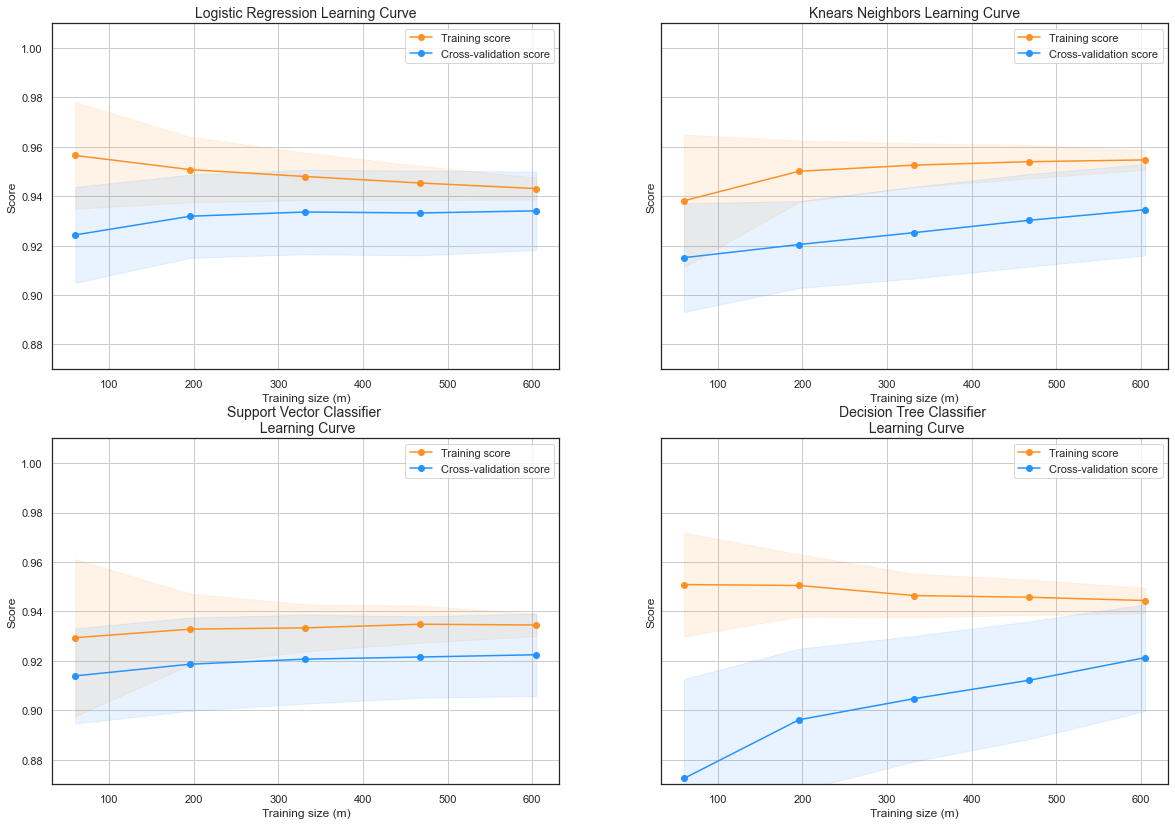

In [414]:
cv = ShuffleSplit(n_splits = 100, test_size = 0.2, random_state = 42)
plot_learning_curve(log_reg, knears_neighbors, svc, tree_clf, X_train, y_train, (0.87, 1.01), cv = cv, n_jobs = 4)

In [415]:
# Create a DataFrame with all the scores and the classifiers names.

log_reg_pred = cross_val_predict(log_reg, X_train, y_train, cv = 5, method = "decision_function")

knears_pred = cross_val_predict(knears_neighbors, X_train, y_train, cv = 5)

svc_pred = cross_val_predict(svc, X_train, y_train, cv = 5, method = "decision_function")

tree_pred = cross_val_predict(tree_clf, X_train, y_train, cv = 5)

In [416]:
print('Logistic Regression: ', roc_auc_score(y_train, log_reg_pred))
print('KNears Neighbors: ', roc_auc_score(y_train, knears_pred))
print('Support Vector Classifier: ', roc_auc_score(y_train, svc_pred))
print('Decision Tree Classifier: ', roc_auc_score(y_train, tree_pred))

Logistic Regression:  0.9744220605346905
KNears Neighbors:  0.9284427528003252
Support Vector Classifier:  0.9756627553237723
Decision Tree Classifier:  0.9188992163295061


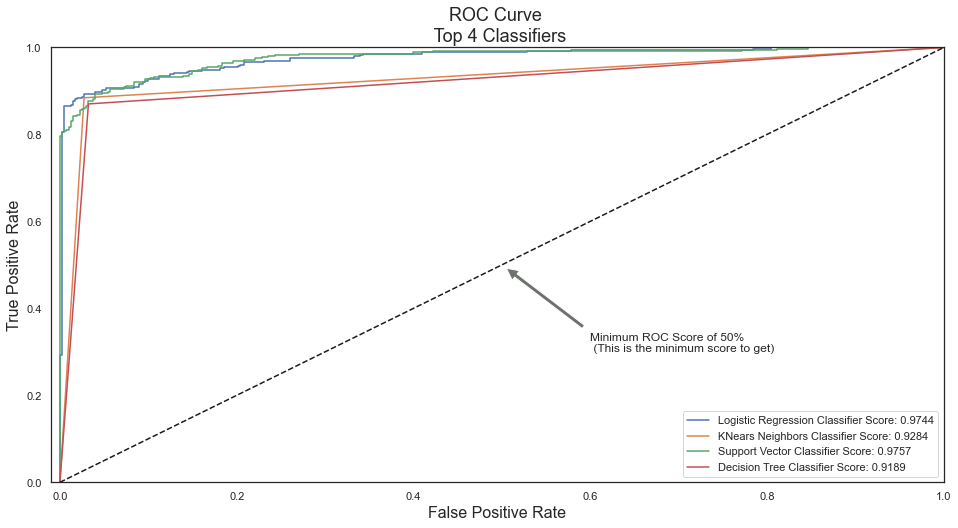

In [417]:
log_fpr, log_tpr, log_thresold = roc_curve(y_train, log_reg_pred)
knear_fpr, knear_tpr, knear_threshold = roc_curve(y_train, knears_pred)
svc_fpr, svc_tpr, svc_threshold = roc_curve(y_train, svc_pred)
tree_fpr, tree_tpr, tree_threshold = roc_curve(y_train, tree_pred)


def graph_roc_curve_multiple(log_fpr, log_tpr, knear_fpr, knear_tpr, svc_fpr, svc_tpr, tree_fpr, tree_tpr):
    plt.figure(figsize=(16,8))
    plt.title('ROC Curve \n Top 4 Classifiers', fontsize = 18)
    plt.plot(log_fpr, log_tpr, label = 'Logistic Regression Classifier Score: {:.4f}'.format(roc_auc_score(y_train, log_reg_pred)))
    plt.plot(knear_fpr, knear_tpr, label = 'KNears Neighbors Classifier Score: {:.4f}'.format(roc_auc_score(y_train, knears_pred)))
    plt.plot(svc_fpr, svc_tpr, label = 'Support Vector Classifier Score: {:.4f}'.format(roc_auc_score(y_train, svc_pred)))
    plt.plot(tree_fpr, tree_tpr, label = 'Decision Tree Classifier Score: {:.4f}'.format(roc_auc_score(y_train, tree_pred)))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([-0.01, 1, 0, 1])
    plt.xlabel('False Positive Rate', fontsize = 16)
    plt.ylabel('True Positive Rate', fontsize = 16)
    plt.annotate('Minimum ROC Score of 50% \n (This is the minimum score to get)', xy = (0.5, 0.5), xytext = (0.6, 0.3),
                arrowprops = dict(facecolor = '#6E726D', shrink = 0.05),
                )
    plt.legend()
    
graph_roc_curve_multiple(log_fpr, log_tpr, knear_fpr, knear_tpr, svc_fpr, svc_tpr, tree_fpr, tree_tpr)
plt.show()

<a id = "2"></a><br>
# A Deeper Look into LogisticRegression

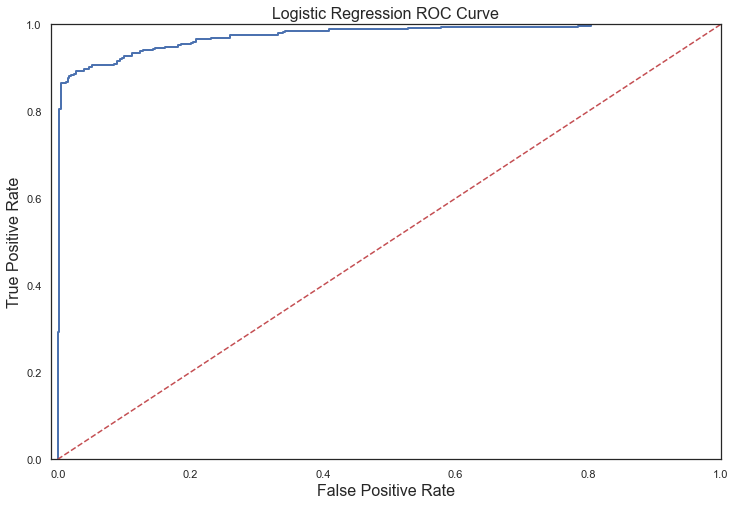

In [418]:
def logistic_roc_curve(log_fpr, log_tpr):
    plt.figure(figsize = (12, 8))
    plt.title('Logistic Regression ROC Curve', fontsize = 16)
    plt.plot(log_fpr, log_tpr, 'b-', linewidth = 2)
    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlabel('False Positive Rate', fontsize = 16)
    plt.ylabel('True Positive Rate', fontsize = 16)
    plt.axis([-0.01, 1, 0, 1])
    
logistic_roc_curve(log_fpr, log_tpr)
plt.show()

In [419]:
precision, recall, threshold = precision_recall_curve(y_train, log_reg_pred)

In [420]:
y_pred = log_reg.predict(X_train)

# Overfitting Case
print('---' * 35)
print('Overfitting: \n')
print('Recall Score: {:.2f}'.format(recall_score(y_train, y_pred)))
print('Precision Score: {:.2f}'.format(precision_score(y_train, y_pred)))
print('F1 Score: {:.2f}'.format(f1_score(y_train, y_pred)))
print('Accuracy Score: {:.2f}'.format(accuracy_score(y_train, y_pred)))
print('---' * 35)

# How it should look like
print('\n')
print('---' * 35)
print('How it should be:\n')
print("Accuracy Score: {:.2f}".format(np.mean(undersample_accuracy)))
print("Precision Score: {:.2f}".format(np.mean(undersample_precision)))
print("Recall Score: {:.2f}".format(np.mean(undersample_recall)))
print("F1 Score: {:.2f}".format(np.mean(undersample_f1)))
print('---' * 35)

---------------------------------------------------------------------------------------------------------
Overfitting: 

Recall Score: 0.91
Precision Score: 0.83
F1 Score: 0.87
Accuracy Score: 0.87
---------------------------------------------------------------------------------------------------------


---------------------------------------------------------------------------------------------------------
How it should be:

Accuracy Score: 0.80
Precision Score: 0.00
Recall Score: 0.19
F1 Score: 0.00
---------------------------------------------------------------------------------------------------------


In [421]:
undersample_y_score = log_reg.decision_function(original_Xtest)

In [422]:
undersample_average_precision = average_precision_score(original_ytest, undersample_y_score)

print('Average precision-recall score: {0:0.2f}'.format(
      undersample_average_precision))

Average precision-recall score: 0.05


Text(0.5, 1.0, 'UnderSampling Precision-Recall curve: \n Average Precision-Recall Score =0.05')

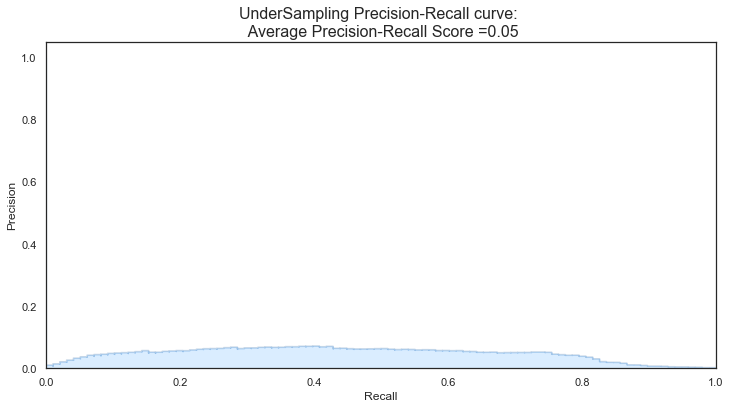

In [423]:
fig = plt.figure(figsize = (12, 6))

precision, recall, _ = precision_recall_curve(original_ytest, undersample_y_score)

plt.step(recall, precision, color = '#004a93', alpha = 0.2, where = 'post')
plt.fill_between(recall, precision, step = 'post', alpha = 0.2, color = '#48a6ff')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('UnderSampling Precision-Recall curve: \n Average Precision-Recall Score ={0:0.2f}'.format(
          undersample_average_precision), fontsize=16)

In [424]:
print('Length of X (train): {} | Length of y (train): {}'.format(len(original_Xtrain), len(original_ytrain)))
print('Length of X (test): {} | Length of y (test): {}'.format(len(original_Xtest), len(original_ytest)))

# List to append the score and then find the average
accuracy_lst = []
precision_lst = []
recall_lst = []
f1_lst = []
auc_lst = []

# Classifier with optimal parameters
# log_reg_sm = grid_log_reg.best_estimator_
log_reg_sm = LogisticRegression()


rand_log_reg = RandomizedSearchCV(LogisticRegression(), log_reg_params, n_iter = 4)


# Implementing SMOTE Technique 
# Cross Validating the right way
# Parameters
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
for train, test in sss.split(original_Xtrain, original_ytrain):
    # SMOTE happens during Cross Validation not before..
    pipeline = imbalanced_make_pipeline(SMOTE(sampling_strategy = 'minority'), rand_log_reg) 
    model = pipeline.fit(original_Xtrain[train], original_ytrain[train])
    best_est = rand_log_reg.best_estimator_
    prediction = best_est.predict(original_Xtrain[test])
    
    accuracy_lst.append(pipeline.score(original_Xtrain[test], original_ytrain[test]))
    precision_lst.append(precision_score(original_ytrain[test], prediction))
    recall_lst.append(recall_score(original_ytrain[test], prediction))
    f1_lst.append(f1_score(original_ytrain[test], prediction))
    auc_lst.append(roc_auc_score(original_ytrain[test], prediction))
    
print('---' * 35)
print('')
print("accuracy: {}".format(np.mean(accuracy_lst)))
print("precision: {}".format(np.mean(precision_lst)))
print("recall: {}".format(np.mean(recall_lst)))
print("f1: {}".format(np.mean(f1_lst)))
print('---' * 35)

Length of X (train): 227846 | Length of y (train): 227846
Length of X (test): 56961 | Length of y (test): 56961
---------------------------------------------------------------------------------------------------------

accuracy: 0.971542346903742
precision: 0.067023806200563
recall: 0.9137617656604998
f1: 0.1236939084564402
---------------------------------------------------------------------------------------------------------


In [425]:
labels = ['No Fraud', 'Fraud']
smote_prediction = best_est.predict(original_Xtest)
print(classification_report(original_ytest, smote_prediction, target_names = labels))

              precision    recall  f1-score   support

    No Fraud       1.00      0.99      0.99     56863
       Fraud       0.11      0.86      0.20        98

    accuracy                           0.99     56961
   macro avg       0.56      0.92      0.60     56961
weighted avg       1.00      0.99      0.99     56961



In [426]:
y_score = best_est.decision_function(original_Xtest)

In [427]:
average_precision = average_precision_score(original_ytest, y_score)

print('Average precision-recall score: {0:0.2f}'.format(
      average_precision))

Average precision-recall score: 0.74


Text(0.5, 1.0, 'OverSampling Precision-Recall curve: \n Average Precision-Recall Score =0.74')

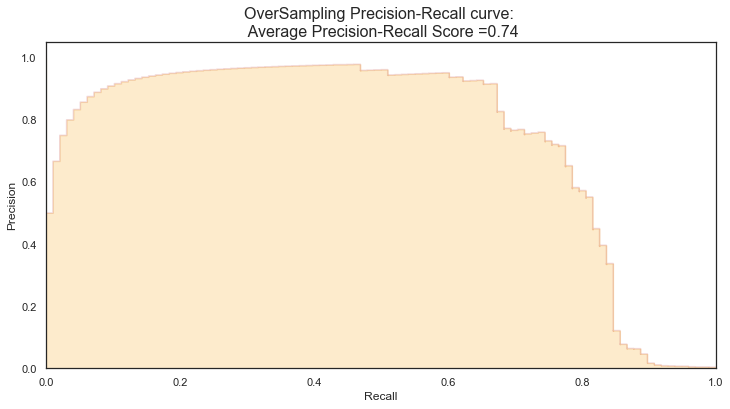

In [428]:
fig = plt.figure(figsize=(12,6))

precision, recall, _ = precision_recall_curve(original_ytest, y_score)

plt.step(recall, precision, color='r', alpha=0.2,
         where='post')
plt.fill_between(recall, precision, step='post', alpha=0.2,
                 color='#F59B00')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('OverSampling Precision-Recall curve: \n Average Precision-Recall Score ={0:0.2f}'.format(
          average_precision), fontsize = 16)

In [431]:
# SMOTE Technique (OverSampling) After splitting and Cross Validating
sm = SMOTE(sampling_strategy = 'minority', random_state = 42)
#Xsm_train, ysm_train = sm.fit_sample(X_train, y_train)


# This will be the data were we are going to 
Xsm_train, ysm_train = sm.fit_sample(original_Xtrain, original_ytrain)

TypeError: __init__() got an unexpected keyword argument 'ratio'

In [430]:
# We Improve the score by 2% points approximately 
# Implement GridSearchCV and the other models.

# Logistic Regression
t0 = time.time()
log_reg_sm = grid_log_reg.best_estimator_
log_reg_sm.fit(Xsm_train, ysm_train)
t1 = time.time()
print("Fitting oversample data took :{} sec".format(t1 - t0))

NameError: name 'Xsm_train' is not defined

<a id = "2"></a><br>
# Test Data with Logistic Regression

## Confusion Matrix

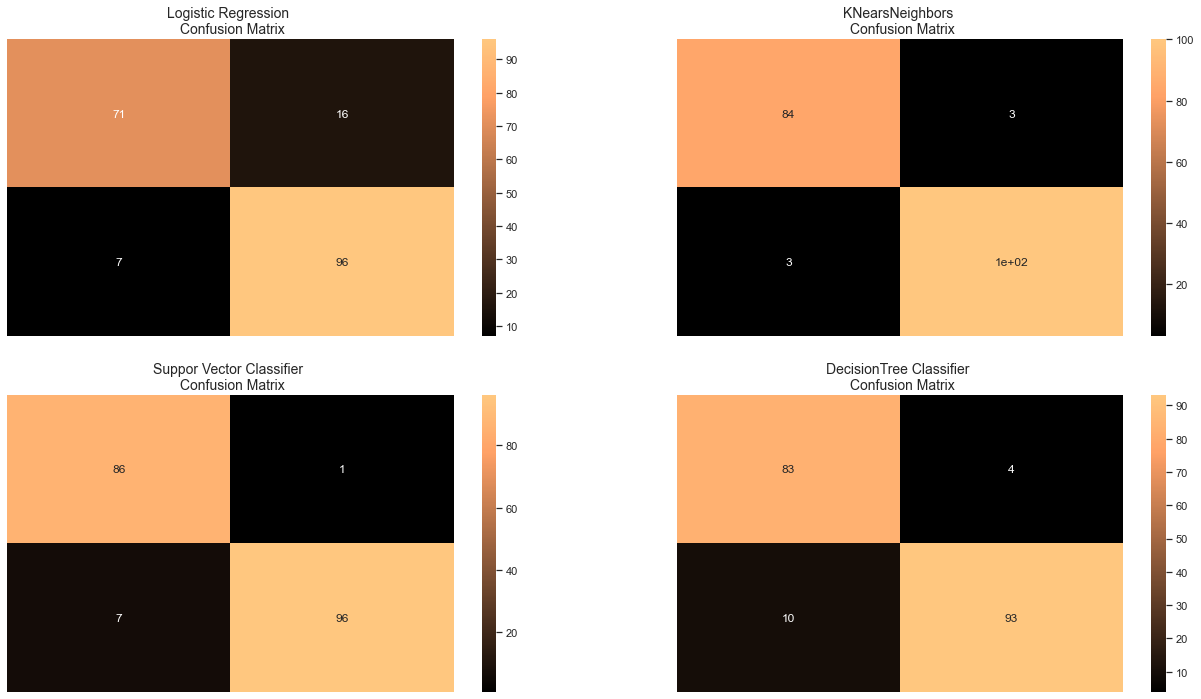

In [432]:
# Logistic Regression fitted using SMOTE technique
y_pred_log_reg = log_reg_sm.predict(X_test)

# Other models fitted with UnderSampling
y_pred_knear = knears_neighbors.predict(X_test)
y_pred_svc = svc.predict(X_test)
y_pred_tree = tree_clf.predict(X_test)


log_reg_cf = confusion_matrix(y_test, y_pred_log_reg)
kneighbors_cf = confusion_matrix(y_test, y_pred_knear)
svc_cf = confusion_matrix(y_test, y_pred_svc)
tree_cf = confusion_matrix(y_test, y_pred_tree)

fig, ax = plt.subplots(2, 2, figsize = (22, 12))


sns.heatmap(log_reg_cf, ax = ax[0][0], annot = True, cmap = plt.cm.copper)
ax[0, 0].set_title("Logistic Regression \n Confusion Matrix", fontsize = 14)
ax[0, 0].set_xticklabels(['', ''], fontsize = 14, rotation = 90)
ax[0, 0].set_yticklabels(['', ''], fontsize = 14, rotation = 360)

sns.heatmap(kneighbors_cf, ax = ax[0][1], annot = True, cmap = plt.cm.copper)
ax[0][1].set_title("KNearsNeighbors \n Confusion Matrix", fontsize = 14)
ax[0][1].set_xticklabels(['', ''], fontsize = 14, rotation = 90)
ax[0][1].set_yticklabels(['', ''], fontsize = 14, rotation = 360)

sns.heatmap(svc_cf, ax = ax[1][0], annot = True, cmap = plt.cm.copper)
ax[1][0].set_title("Suppor Vector Classifier \n Confusion Matrix", fontsize = 14)
ax[1][0].set_xticklabels(['', ''], fontsize = 14, rotation = 90)
ax[1][0].set_yticklabels(['', ''], fontsize = 14, rotation = 360)

sns.heatmap(tree_cf, ax = ax[1][1], annot = True, cmap = plt.cm.copper)
ax[1][1].set_title("DecisionTree Classifier \n Confusion Matrix", fontsize = 14)
ax[1][1].set_xticklabels(['', ''], fontsize = 14, rotation = 90)
ax[1][1].set_yticklabels(['', ''], fontsize = 14, rotation = 360)


plt.show()

In [433]:
print('Logistic Regression:')
print(classification_report(y_test, y_pred_log_reg))

print('KNears Neighbors:')
print(classification_report(y_test, y_pred_knear))

print('Support Vector Classifier:')
print(classification_report(y_test, y_pred_svc))

print('Support Vector Classifier:')
print(classification_report(y_test, y_pred_tree))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.91      0.82      0.86        87
           1       0.86      0.93      0.89       103

    accuracy                           0.88       190
   macro avg       0.88      0.87      0.88       190
weighted avg       0.88      0.88      0.88       190

KNears Neighbors:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        87
           1       0.97      0.97      0.97       103

    accuracy                           0.97       190
   macro avg       0.97      0.97      0.97       190
weighted avg       0.97      0.97      0.97       190

Support Vector Classifier:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96        87
           1       0.99      0.93      0.96       103

    accuracy                           0.96       190
   macro avg       0.96      0.96      0.96       190
weighted

In [434]:
# Logistic Regression with Under-Sampling
y_pred = log_reg.predict(X_test)
undersample_score = accuracy_score(y_test, y_pred)



# Logistic Regression with SMOTE Technique (Better accuracy with SMOTE t)
y_pred_sm = best_est.predict(original_Xtest)
oversample_score = accuracy_score(original_ytest, y_pred_sm)


d = {'Technique': ['Random UnderSampling', 'Oversampling (SMOTE)'], 'Score': [undersample_score, oversample_score]}
final_df = pd.DataFrame(data=d)

# Move column
score = final_df['Score']
final_df.drop('Score', axis=1, inplace=True)
final_df.insert(1, 'Score', score)

# Note how high is accuracy score it can be misleading! 
final_df

,Technique,Score
0,Random UnderSampling,0.879
1,Oversampling (SMOTE),0.988


<a id = "2"></a><br>
# Random Forest Classifier


Random forest model is an ensemble of classification (or regression) trees.The popularity of decision tree models in data mining arises from their ease of use, flexibility in terms of handling various data attribute types, and interpretability. Single tree models, however, can be unstable and overly sensitive to specific training data. Ensemble methods seek to address this problem by developing a set of models and aggregating their predictions in determining the class label for a data point. Ensembles perform well when individual members are dissimilar, and random forests obtain variation among individual trees using two sources for randomness: first, each tree is built on separate bootstrapped samples of the training data; secondly, only a randomly selected subset of data is considered at each node in building the individual trees. Random forests thus combine the concepts of bagging, where individual models in an ensemble are developed through sampling with replacement from the training data, and the random subspace method, where each tree in an ensemble is built from a random subset of attributes. Given a training data set of N cases described by B attributes, each tree in the ensemble is developed as follows:


* Obtain a bootstrap sample of N cases.
* At each node, randomly select a subset of bbB attributes. Determine the best split at the node from this reduced set of b attributes
* Grow the full tree without pruning

Random forests are computationally efficient since each tree is built independently of the others. With large number of trees in the ensemble, they are also noted to be robust to over fitting and noise in the data.

In [86]:
RFC = RandomForestClassifier(random_state = 0, n_estimators = 100,
                                    criterion = 'entropy')

In [87]:
RFC.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='entropy', max_depth=None, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=0, verbose=0,
                       warm_start=False)

In [88]:
# Predicting Test Set
y_pred = RFC.predict(X_test)

In [89]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [90]:
model_results = pd.DataFrame([['Random Forest (n = 100)', acc, prec, rec, f1]],
               columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

results = results.append(model_results, ignore_index = True)

In [91]:
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision tree,0.999,0.836,0.762,0.797
1,Random Forest (n = 100),1.000,0.942,0.769,0.846


[[85289     7]
 [   34   113]]


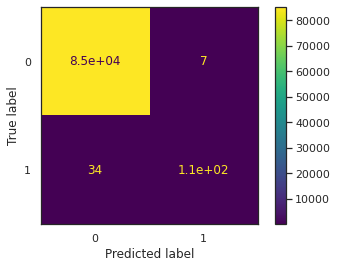

In [93]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plot_confusion_matrix(RFC, X_test, y_test)  
plt.show()  